In [1]:
print("Hello Mini Project")

Hello Mini Project


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Mini_Project_II.csv")

df.head()

,LoadType,Condition,Vrms,Irms,RealPower,PF
0,Incandescent,Healthy,229.2,0.4247,94.15,0.967
1,Incandescent,Healthy,231.7,0.4248,99.83,1.000
2,Incandescent,Healthy,230.2,0.4255,95.74,0.978
3,Incandescent,Healthy,231.0,0.4254,95.91,0.976
4,Incandescent,Healthy,231.1,0.4250,95.31,0.970


In [4]:
print(df.shape)

df.info()

(1229, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1229 entries, 0 to 1228
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LoadType   1229 non-null   object 
 1   Condition  1229 non-null   object 
 2   Vrms       1229 non-null   float64
 3   Irms       1229 non-null   float64
 4   RealPower  1229 non-null   float64
 5   PF         1229 non-null   float64
dtypes: float64(4), object(2)
memory usage: 57.7+ KB


In [5]:
df["Vrms"] = df["Vrms"].astype(str)

df["Vrms"] = df["Vrms"].str.replace("V", "", regex=False)

df["Vrms"] = df["Vrms"].str.strip()

df["Vrms"] = df["Vrms"].astype(float)

In [6]:
df["Vrms"] = df["Vrms"].astype(str)

df["Vrms"] = df["Vrms"].str.replace("Vrms:", "", regex=False)

df["Vrms"] = df["Vrms"].str.replace("V", "", regex=False)

df["Vrms"] = df["Vrms"].str.strip()

df["Vrms"] = pd.to_numeric(df["Vrms"], errors="coerce")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1229 entries, 0 to 1228
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LoadType   1229 non-null   object 
 1   Condition  1229 non-null   object 
 2   Vrms       1229 non-null   float64
 3   Irms       1229 non-null   float64
 4   RealPower  1229 non-null   float64
 5   PF         1229 non-null   float64
dtypes: float64(4), object(2)
memory usage: 57.7+ KB


In [8]:
print(df.isnull().sum())

LoadType     0
Condition    0
Vrms         0
Irms         0
RealPower    0
PF           0
dtype: int64


In [9]:
bad_rows = df[df["Vrms"].isnull()]

bad_rows.head(20)

,LoadType,Condition,Vrms,Irms,RealPower,PF


In [10]:
print(df.shape)

df.info()

(1229, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1229 entries, 0 to 1228
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LoadType   1229 non-null   object 
 1   Condition  1229 non-null   object 
 2   Vrms       1229 non-null   float64
 3   Irms       1229 non-null   float64
 4   RealPower  1229 non-null   float64
 5   PF         1229 non-null   float64
dtypes: float64(4), object(2)
memory usage: 57.7+ KB


In [11]:
df["LoadType"] = df["LoadType"].map({
    "LED": 0,
    "Incandescent": 1,
    "Fan": 2
})

df["Condition"] = df["Condition"].map({
    "Healthy": 0,
    "Mild": 1,
    "Moderate": 2,
    "Severe": 3
})

In [12]:
df.head()

,LoadType,Condition,Vrms,Irms,RealPower,PF
0,1,0,229.2,0.4247,94.15,0.967
1,1,0,231.7,0.4248,99.83,1.000
2,1,0,230.2,0.4255,95.74,0.978
3,1,0,231.0,0.4254,95.91,0.976
4,1,0,231.1,0.4250,95.31,0.970


In [13]:
df["ApparentPower"] = df["Vrms"] * df["Irms"]

In [14]:
df["SP_Ratio"] = df["ApparentPower"] / df["RealPower"]

In [15]:
df["CurrentPerWatt"] = df["Irms"] / df["RealPower"]

In [16]:
df.head()

,LoadType,Condition,Vrms,Irms,RealPower,PF,ApparentPower,SP_Ratio,CurrentPerWatt
0,1,0,229.2,0.4247,94.15,0.967,97.34124,1.033895,0.004511
1,1,0,231.7,0.4248,99.83,1.000,98.42616,0.985938,0.004255
2,1,0,230.2,0.4255,95.74,0.978,97.95010,1.023084,0.004444
3,1,0,231.0,0.4254,95.91,0.976,98.26740,1.024579,0.004435
4,1,0,231.1,0.4250,95.31,0.970,98.21750,1.030506,0.004459


In [17]:
df["PF_Drift"] = df["PF"].diff()

df["Current_Drift"] = df["Irms"].diff()

df["Power_Drift"] = df["RealPower"].diff()

In [18]:
df.head()

,LoadType,Condition,Vrms,Irms,RealPower,PF,ApparentPower,SP_Ratio,CurrentPerWatt,PF_Drift,Current_Drift,Power_Drift
0,1,0,229.2,0.4247,94.15,0.967,97.34124,1.033895,0.004511,NaN,NaN,NaN
1,1,0,231.7,0.4248,99.83,1.000,98.42616,0.985938,0.004255,0.033,0.0001,5.68
2,1,0,230.2,0.4255,95.74,0.978,97.95010,1.023084,0.004444,-0.022,0.0007,-4.09
3,1,0,231.0,0.4254,95.91,0.976,98.26740,1.024579,0.004435,-0.002,-0.0001,0.17
4,1,0,231.1,0.4250,95.31,0.970,98.21750,1.030506,0.004459,-0.006,-0.0004,-0.60


In [19]:
df.drop(columns=[
    "PF_Drift",
    "Current_Drift",
    "Power_Drift"
], inplace=True)

In [20]:
df["PF_Drift"] = df.groupby("LoadType")["PF"].diff()

df["Current_Drift"] = df.groupby("LoadType")["Irms"].diff()

df["Power_Drift"] = df.groupby("LoadType")["RealPower"].diff()

In [21]:
df.head()

,LoadType,Condition,Vrms,Irms,RealPower,PF,ApparentPower,SP_Ratio,CurrentPerWatt,PF_Drift,Current_Drift,Power_Drift
0,1,0,229.2,0.4247,94.15,0.967,97.34124,1.033895,0.004511,NaN,NaN,NaN
1,1,0,231.7,0.4248,99.83,1.000,98.42616,0.985938,0.004255,0.033,0.0001,5.68
2,1,0,230.2,0.4255,95.74,0.978,97.95010,1.023084,0.004444,-0.022,0.0007,-4.09
3,1,0,231.0,0.4254,95.91,0.976,98.26740,1.024579,0.004435,-0.002,-0.0001,0.17
4,1,0,231.1,0.4250,95.31,0.970,98.21750,1.030506,0.004459,-0.006,-0.0004,-0.60


In [22]:
df["RollingMean_Power"] = (
    df.groupby("LoadType")["RealPower"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

df["RollingMean_PF"] = (
    df.groupby("LoadType")["PF"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

df["RollingMean_Current"] = (
    df.groupby("LoadType")["Irms"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

In [23]:
df.drop(columns=[
    "PF_Drift",
    "Current_Drift",
    "Power_Drift",
    "RollingMean_Power",
    "RollingMean_PF",
    "RollingMean_Current"
], inplace=True)

In [24]:
df["PF_Drift"] = (
    df.groupby(["LoadType", "Condition"])["PF"]
    .diff()
)

df["Current_Drift"] = (
    df.groupby(["LoadType", "Condition"])["Irms"]
    .diff()
)

df["Power_Drift"] = (
    df.groupby(["LoadType", "Condition"])["RealPower"]
    .diff()
)

In [25]:
df["RollingMean_Power"] = (
    df.groupby(["LoadType", "Condition"])["RealPower"]
    .rolling(5)
    .mean()
    .reset_index(level=[0,1], drop=True)
)

df["RollingMean_PF"] = (
    df.groupby(["LoadType", "Condition"])["PF"]
    .rolling(5)
    .mean()
    .reset_index(level=[0,1], drop=True)
)

df["RollingMean_Current"] = (
    df.groupby(["LoadType", "Condition"])["Irms"]
    .rolling(5)
    .mean()
    .reset_index(level=[0,1], drop=True)
)

In [26]:
df.drop(columns=[
    "PF_Drift",
    "Current_Drift",
    "Power_Drift",
    "RollingMean_Power",
    "RollingMean_PF",
    "RollingMean_Current"
], inplace=True)

In [27]:
df["PF_Drift"] = (
    df.groupby("LoadType")["PF"]
    .diff()
)

df["Current_Drift"] = (
    df.groupby("LoadType")["Irms"]
    .diff()
)

df["Power_Drift"] = (
    df.groupby("LoadType")["RealPower"]
    .diff()
)

In [28]:
df["RollingMean_Power"] = (
    df.groupby("LoadType")["RealPower"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

df["RollingMean_PF"] = (
    df.groupby("LoadType")["PF"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

df["RollingMean_Current"] = (
    df.groupby("LoadType")["Irms"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

In [29]:
df["RollingStd_Power"] = (
    df.groupby("LoadType")["RealPower"]
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)

df["RollingStd_PF"] = (
    df.groupby("LoadType")["PF"]
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)

df["RollingStd_Current"] = (
    df.groupby("LoadType")["Irms"]
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)

In [30]:
df.head(10)

,LoadType,Condition,Vrms,Irms,RealPower,PF,ApparentPower,SP_Ratio,CurrentPerWatt,PF_Drift,Current_Drift,Power_Drift,RollingMean_Power,RollingMean_PF,RollingMean_Current,RollingStd_Power,RollingStd_PF,RollingStd_Current
0,1,0,229.2,0.4247,94.15,0.967,97.34124,1.033895,0.004511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0,231.7,0.4248,99.83,1.000,98.42616,0.985938,0.004255,0.033,0.0001,5.68,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0,230.2,0.4255,95.74,0.978,97.95010,1.023084,0.004444,-0.022,0.0007,-4.09,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0,231.0,0.4254,95.91,0.976,98.26740,1.024579,0.004435,-0.002,-0.0001,0.17,NaN,NaN,NaN,NaN,NaN,NaN
4,1,0,231.1,0.4250,95.31,0.970,98.21750,1.030506,0.004459,-0.006,-0.0004,-0.60,96.188,0.9782,0.42508,2.148632,0.012969,0.000356
5,1,0,230.5,0.4251,95.02,0.970,97.98555,1.031210,0.004474,0.000,0.0001,-0.29,96.362,0.9788,0.42516,1.970145,0.012377,0.000288
6,1,0,229.4,0.4255,94.73,0.970,97.60970,1.030399,0.004492,0.000,0.0004,-0.29,95.342,0.9728,0.42530,0.489969,0.003899,0.000235
7,1,0,230.8,0.4248,96.24,0.982,98.04384,1.018743,0.004414,0.012,-0.0007,1.51,95.442,0.9736,0.42516,0.624155,0.005367,0.000288
8,1,0,230.8,0.4250,96.40,0.983,98.09000,1.017531,0.004409,0.001,0.0002,0.16,95.540,0.9750,0.42508,0.743135,0.006856,0.000259
9,1,0,230.6,0.4251,95.97,0.979,98.02806,1.021445,0.004430,-0.004,0.0001,-0.43,95.672,0.9768,0.42510,0.750646,0.006380,0.000255


In [31]:
df.dropna(inplace=True)

In [32]:
print(df.shape)

print(df.isnull().sum())

(1217, 18)
LoadType               0
Condition              0
Vrms                   0
Irms                   0
RealPower              0
PF                     0
ApparentPower          0
SP_Ratio               0
CurrentPerWatt         0
PF_Drift               0
Current_Drift          0
Power_Drift            0
RollingMean_Power      0
RollingMean_PF         0
RollingMean_Current    0
RollingStd_Power       0
RollingStd_PF          0
RollingStd_Current     0
dtype: int64


In [33]:
df["Target_Next_Power"] = (
    df.groupby("LoadType")["RealPower"]
    .shift(-1)
)

In [34]:
df.dropna(inplace=True)

In [35]:
print(df.shape)

df.head()

(1214, 19)


,LoadType,Condition,Vrms,Irms,RealPower,PF,ApparentPower,SP_Ratio,CurrentPerWatt,PF_Drift,Current_Drift,Power_Drift,RollingMean_Power,RollingMean_PF,RollingMean_Current,RollingStd_Power,RollingStd_PF,RollingStd_Current,Target_Next_Power
4,1,0,231.1,0.4250,95.31,0.970,98.21750,1.030506,0.004459,-0.006,-0.0004,-0.60,96.188,0.9782,0.42508,2.148632,0.012969,0.000356,95.02
5,1,0,230.5,0.4251,95.02,0.970,97.98555,1.031210,0.004474,0.000,0.0001,-0.29,96.362,0.9788,0.42516,1.970145,0.012377,0.000288,94.73
6,1,0,229.4,0.4255,94.73,0.970,97.60970,1.030399,0.004492,0.000,0.0004,-0.29,95.342,0.9728,0.42530,0.489969,0.003899,0.000235,96.24
7,1,0,230.8,0.4248,96.24,0.982,98.04384,1.018743,0.004414,0.012,-0.0007,1.51,95.442,0.9736,0.42516,0.624155,0.005367,0.000288,96.40
8,1,0,230.8,0.4250,96.40,0.983,98.09000,1.017531,0.004409,0.001,0.0002,0.16,95.540,0.9750,0.42508,0.743135,0.006856,0.000259,95.97


In [36]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 932.9 kB/s eta 0:01:49
   ---------------------------------------- 0.8/101.7 MB 1.0 MB/s eta 0:01:40
   ---------------------------------------- 1.0/101.7 MB 1.1 MB/s eta 0:01:30
    --------------------------------------- 1.3/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 1.6/101.7 MB 1.3 MB/s eta 0:01:20
    --------------------------------------- 2.1/101.7 MB 1.4 MB/s eta 0:01:14
    --------------------------------------- 2.4/101.7 MB 1.4 MB/s eta 0:01:12
   - -------------------------------------- 2.9/101.7 MB 1.5 MB/s eta 0:01:06
   - -------------------------------------- 3.4/101.7 MB 1.6 MB/s eta 0:01:03
   - -------------------------------------- 3.7/101.7 MB 1.6 MB/s eta 0:01:03
   - 


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

In [39]:
features = [
    "LoadType",
    "Condition",
    "Vrms",
    "Irms",
    "RealPower",
    "PF",
    "ApparentPower",
    "SP_Ratio",
    "CurrentPerWatt",
    "PF_Drift",
    "Current_Drift",
    "Power_Drift",
    "RollingMean_Power",
    "RollingMean_PF",
    "RollingMean_Current",
    "RollingStd_Power",
    "RollingStd_PF",
    "RollingStd_Current"
]

In [40]:
X = df[features]

y = df["Target_Next_Power"]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

In [43]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [44]:
predictions = model.predict(X_test)

In [45]:
mae = mean_absolute_error(y_test, predictions)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.535389496210671
RMSE: 1.4375071939907573


In [46]:
results = X_test.copy()

results["ActualPower"] = y_test.values

results["PredictedPower"] = predictions

results["PredictionError"] = abs(
    results["ActualPower"] -
    results["PredictedPower"]
)

In [47]:
results.head(10)

,LoadType,Condition,Vrms,Irms,RealPower,PF,ApparentPower,SP_Ratio,CurrentPerWatt,PF_Drift,...,Power_Drift,RollingMean_Power,RollingMean_PF,RollingMean_Current,RollingStd_Power,RollingStd_PF,RollingStd_Current,ActualPower,PredictedPower,PredictionError
752,0,0,232.6,0.0401,7.16,0.768,9.32726,1.302690,0.005601,0.016,...,0.22,6.960,0.7516,0.04012,0.193003,0.017869,0.000130,6.81,6.944947,0.134947
801,0,0,231.1,0.0401,6.93,0.748,9.26711,1.337245,0.005786,-0.030,...,-0.25,7.068,0.7668,0.03998,0.160219,0.016814,0.000084,6.93,7.039525,0.109525
47,1,0,229.6,0.4248,96.36,0.988,97.53408,1.012184,0.004408,-0.003,...,-1.28,96.770,0.9870,0.42500,0.499600,0.002646,0.000324,96.58,97.031883,0.451883
159,1,0,229.2,0.4247,94.15,0.967,97.34124,1.033895,0.004511,-0.015,...,-1.92,96.394,0.9838,0.42506,1.488180,0.010686,0.000336,99.83,97.044434,2.785566
506,2,3,223.4,0.4278,64.21,0.672,95.57052,1.488406,0.006663,0.012,...,4.66,60.814,0.6648,0.40950,2.032715,0.006099,0.010351,65.58,65.621941,0.041941
982,0,0,231.4,0.0403,8.40,0.901,9.32542,1.110169,0.004798,0.020,...,0.28,8.270,0.8914,0.04022,0.121450,0.009659,0.000045,8.39,8.146178,0.243822
282,1,0,232.3,0.4248,98.44,0.999,98.68104,1.002449,0.004315,0.010,...,1.56,96.862,0.9888,0.42504,1.151399,0.007085,0.000230,96.31,96.586357,0.276357
603,2,0,240.1,0.4014,61.78,0.641,96.37614,1.559989,0.006497,0.036,...,10.44,62.832,0.6632,0.41644,6.843414,0.039003,0.026758,62.08,61.034966,1.045034
127,1,0,230.5,0.4249,96.27,0.983,97.93945,1.017341,0.004414,0.003,...,-0.42,96.166,0.9804,0.42524,0.967409,0.008620,0.000288,96.32,95.636063,0.683937
117,1,0,231.5,0.4247,96.58,0.982,98.31805,1.017996,0.004397,0.003,...,0.61,95.984,0.9792,0.42502,0.735955,0.005357,0.000311,96.57,96.325195,0.244805


In [48]:
def anomaly_status(error):

    if error < 1:
        return "Healthy"

    elif error < 3:
        return "Mild Deviation"

    elif error < 6:
        return "Moderate Deviation"

    else:
        return "Severe Deviation"

In [49]:
results["SystemStatus"] = results[
    "PredictionError"
].apply(anomaly_status)

In [50]:
results[[
    "ActualPower",
    "PredictedPower",
    "PredictionError",
    "SystemStatus"
]].head(20)

,ActualPower,PredictedPower,PredictionError,SystemStatus
752,6.81,6.944947,0.134947,Healthy
801,6.93,7.039525,0.109525,Healthy
47,96.58,97.031883,0.451883,Healthy
159,99.83,97.044434,2.785566,Mild Deviation
506,65.58,65.621941,0.041941,Healthy
982,8.39,8.146178,0.243822,Healthy
282,96.31,96.586357,0.276357,Healthy
603,62.08,61.034966,1.045034,Mild Deviation
127,96.32,95.636063,0.683937,Healthy
117,96.57,96.325195,0.244805,Healthy


In [51]:
def electrical_interpretation(row):

    error = row["PredictionError"]

    pf_drift = row["PF_Drift"]

    current_std = row["RollingStd_Current"]

    power_std = row["RollingStd_Power"]


    if error < 1:
        return "Normal operation"

    elif pf_drift < -0.01:
        return "Possible PF degradation detected"

    elif current_std > 0.003:
        return "Possible current instability detected"

    elif power_std > 3:
        return "Possible abnormal power fluctuation"

    else:
        return "Possible appliance degradation"

In [52]:
results["Interpretation"] = results.apply(
    electrical_interpretation,
    axis=1
)

In [53]:
results[[
    "ActualPower",
    "PredictedPower",
    "PredictionError",
    "SystemStatus",
    "Interpretation"
]].head(20)

,ActualPower,PredictedPower,PredictionError,SystemStatus,Interpretation
752,6.81,6.944947,0.134947,Healthy,Normal operation
801,6.93,7.039525,0.109525,Healthy,Normal operation
47,96.58,97.031883,0.451883,Healthy,Normal operation
159,99.83,97.044434,2.785566,Mild Deviation,Possible PF degradation detected
506,65.58,65.621941,0.041941,Healthy,Normal operation
982,8.39,8.146178,0.243822,Healthy,Normal operation
282,96.31,96.586357,0.276357,Healthy,Normal operation
603,62.08,61.034966,1.045034,Mild Deviation,Possible current instability detected
127,96.32,95.636063,0.683937,Healthy,Normal operation
117,96.57,96.325195,0.244805,Healthy,Normal operation


In [54]:
importance = model.feature_importances_

for feature, score in zip(features, importance):
    print(feature, ":", round(score, 4))

LoadType : 0.9903
Condition : 0.0002
Vrms : 0.0
Irms : 0.0011
RealPower : 0.0012
PF : 0.0039
ApparentPower : 0.0005
SP_Ratio : 0.0016
CurrentPerWatt : 1e-04
PF_Drift : 1e-04
Current_Drift : 0.0
Power_Drift : 1e-04
RollingMean_Power : 0.0002
RollingMean_PF : 0.0002
RollingMean_Current : 0.0004
RollingStd_Power : 0.0
RollingStd_PF : 0.0
RollingStd_Current : 1e-04


In [56]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.2 MB 8.4 MB/s eta 0:00:01
   ------------ --------------------------- 2.6/8.2 MB 6.3 MB/s eta 0:00:01
   -------------- ------------------------- 2.9/8.2 MB 6.2 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.2 MB 5.0 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.2 MB 5.4 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.2 MB 5.2 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.2 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 4.5 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.3 MB 5.6 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.3 MB 5.9 MB/s eta 0:00:01
   --------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
import matplotlib.pyplot as plt

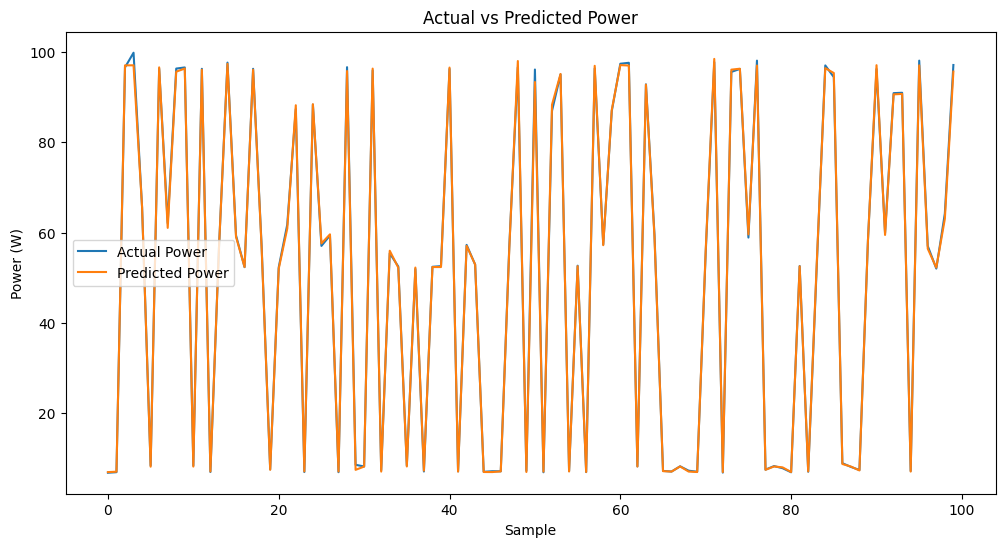

In [58]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:100],
    label="Actual Power"
)

plt.plot(
    predictions[:100],
    label="Predicted Power"
)

plt.legend()

plt.xlabel("Sample")

plt.ylabel("Power (W)")

plt.title("Actual vs Predicted Power")

plt.show()

In [59]:
fan_results = results[
    results["LoadType"] == 0
]

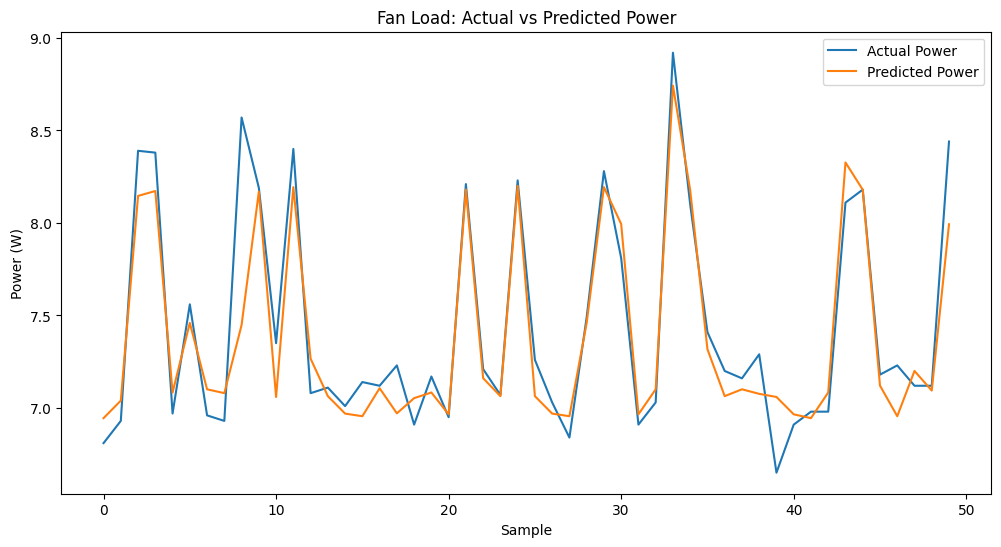

In [60]:
plt.figure(figsize=(12,6))

plt.plot(
    fan_results["ActualPower"].values[:50],
    label="Actual Power"
)

plt.plot(
    fan_results["PredictedPower"].values[:50],
    label="Predicted Power"
)

plt.legend()

plt.xlabel("Sample")

plt.ylabel("Power (W)")

plt.title("Fan Load: Actual vs Predicted Power")

plt.show()

In [61]:
print(df["LoadType"].unique())

[1 0 2]


In [62]:
df[["LoadType"]].drop_duplicates()

,LoadType
4,1
216,0
247,2


In [63]:
df.groupby("LoadType")["RealPower"].mean()

LoadType
0     7.478941
1    95.349605
2    56.032800
Name: RealPower, dtype: float64

In [64]:
fan_results = results[
    results["LoadType"] == 2
]

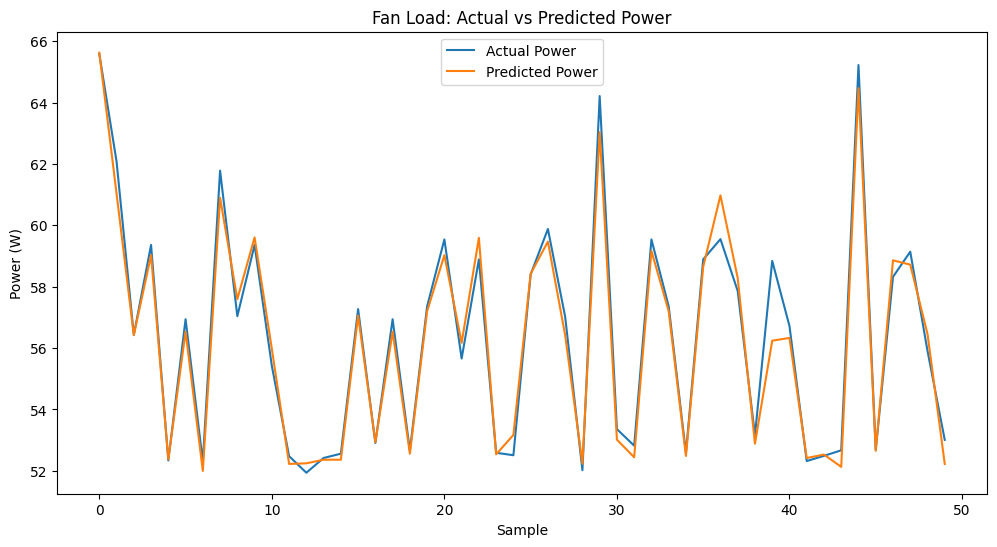

In [65]:
plt.figure(figsize=(12,6))

plt.plot(
    fan_results["ActualPower"].values[:50],
    label="Actual Power"
)

plt.plot(
    fan_results["PredictedPower"].values[:50],
    label="Predicted Power"
)

plt.legend()

plt.xlabel("Sample")

plt.ylabel("Power (W)")

plt.title("Fan Load: Actual vs Predicted Power")

plt.show()


In [66]:
df.groupby("LoadType")["RealPower"].mean()

LoadType
0     7.478941
1    95.349605
2    56.032800
Name: RealPower, dtype: float64

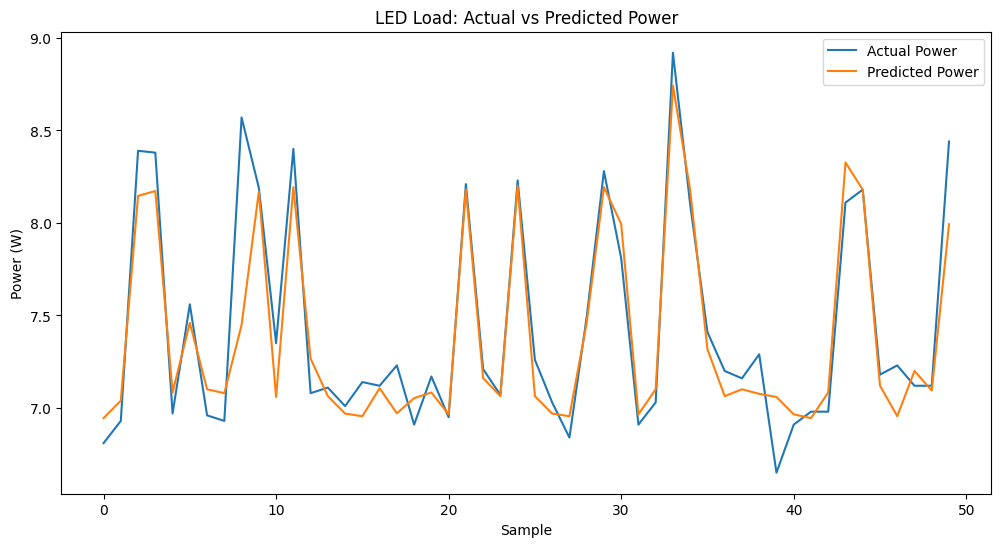

In [67]:
led_results = results[
    results["LoadType"] == 0
]

plt.figure(figsize=(12,6))

plt.plot(
    led_results["ActualPower"].values[:50],
    label="Actual Power"
)

plt.plot(
    led_results["PredictedPower"].values[:50],
    label="Predicted Power"
)

plt.legend()

plt.xlabel("Sample")

plt.ylabel("Power (W)")

plt.title("LED Load: Actual vs Predicted Power")

plt.show()

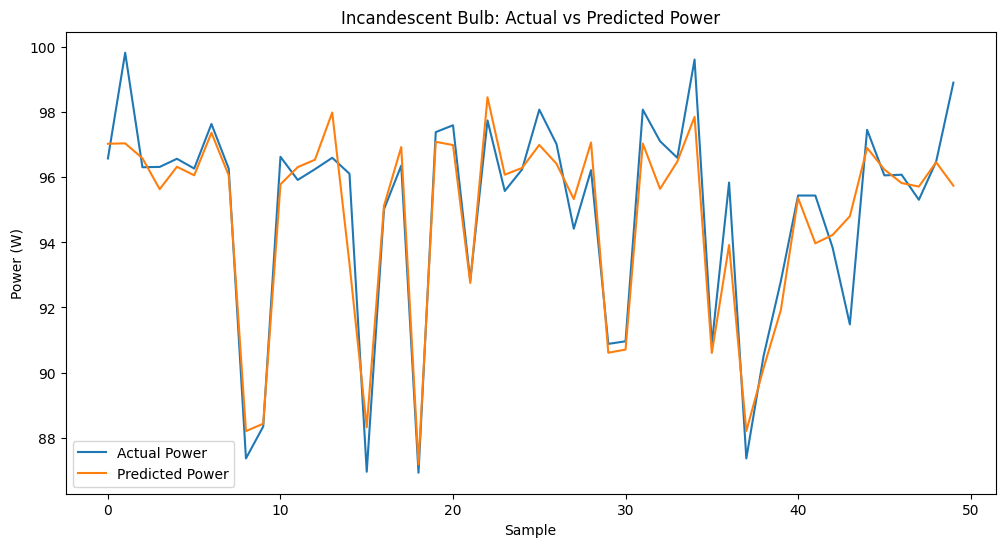

In [68]:
bulb_results = results[
    results["LoadType"] == 1
]

plt.figure(figsize=(12,6))

plt.plot(
    bulb_results["ActualPower"].values[:50],
    label="Actual Power"
)

plt.plot(
    bulb_results["PredictedPower"].values[:50],
    label="Predicted Power"
)

plt.legend()

plt.xlabel("Sample")

plt.ylabel("Power (W)")

plt.title("Incandescent Bulb: Actual vs Predicted Power")

plt.show()

In [69]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
0,LoadType,0.990270
5,PF,0.003864
7,SP_Ratio,0.001646
4,RealPower,0.001164
3,Irms,0.001080
6,ApparentPower,0.000536
14,RollingMean_Current,0.000430
1,Condition,0.000231
13,RollingMean_PF,0.000199
12,RollingMean_Power,0.000154


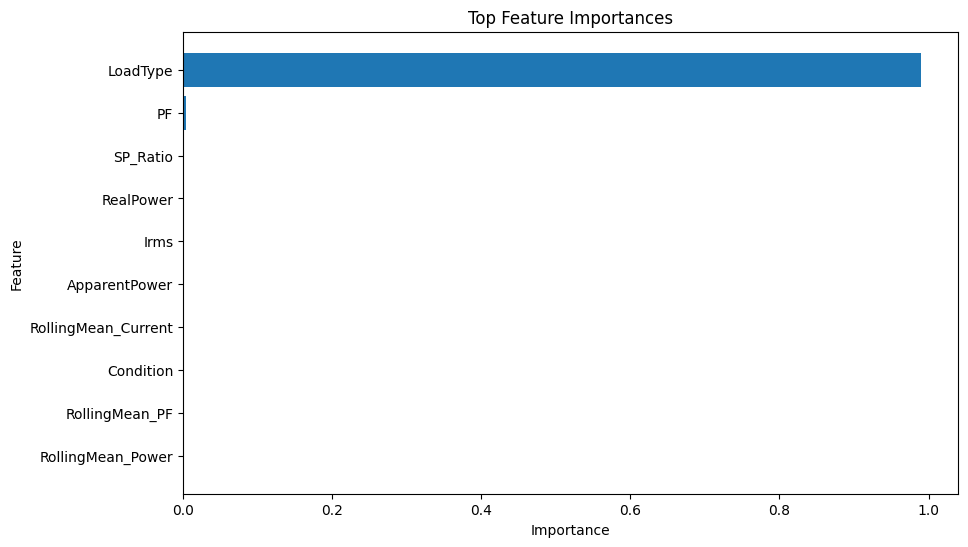

In [70]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"][:10],
    importance_df["Importance"][:10]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top Feature Importances")

plt.gca().invert_yaxis()

plt.show()

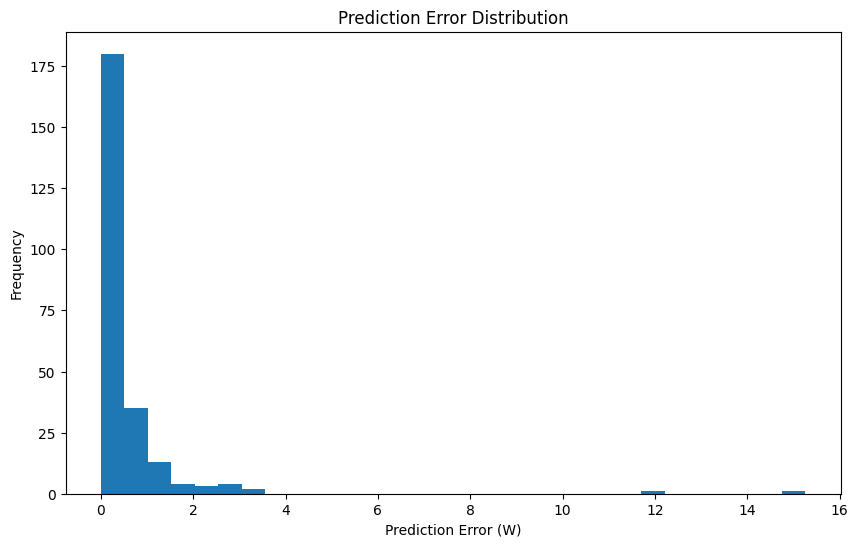

In [71]:
plt.figure(figsize=(10,6))

plt.hist(
    results["PredictionError"],
    bins=30
)

plt.xlabel("Prediction Error (W)")

plt.ylabel("Frequency")

plt.title("Prediction Error Distribution")

plt.show()

In [72]:
df.groupby("LoadType")["PF"].mean()

LoadType
0    0.796831
1    0.969438
2    0.644811
Name: PF, dtype: float64

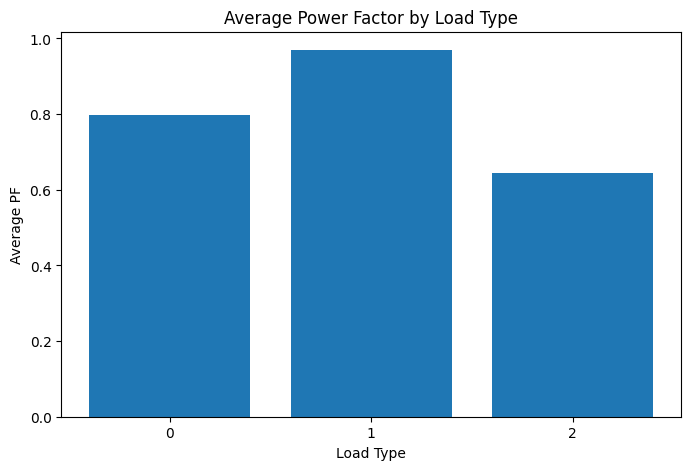

In [73]:
pf_means = df.groupby("LoadType")["PF"].mean()

plt.figure(figsize=(8,5))

plt.bar(
    pf_means.index.astype(str),
    pf_means.values
)

plt.xlabel("Load Type")

plt.ylabel("Average PF")

plt.title("Average Power Factor by Load Type")

plt.show()

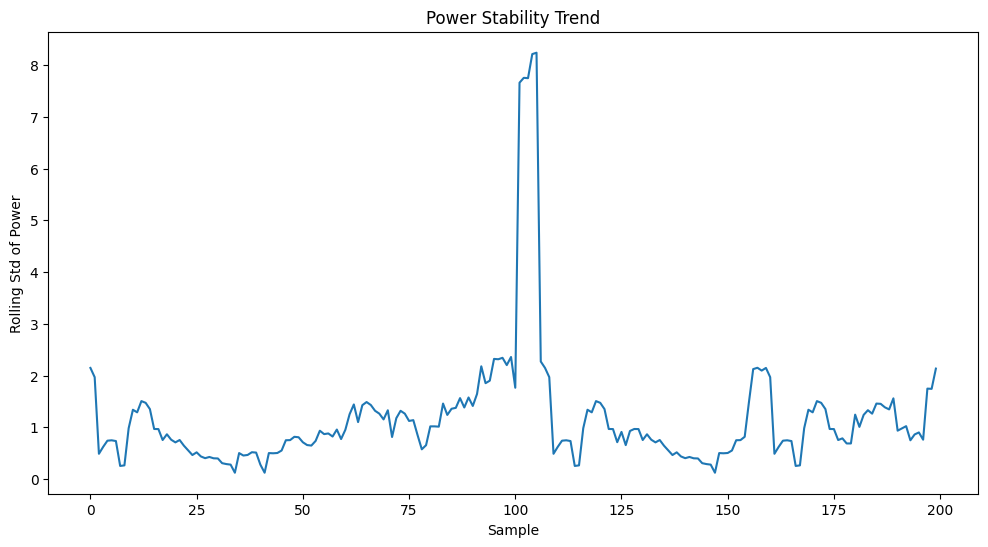

In [74]:
plt.figure(figsize=(12,6))

plt.plot(
    df["RollingStd_Power"].values[:200]
)

plt.xlabel("Sample")

plt.ylabel("Rolling Std of Power")

plt.title("Power Stability Trend")

plt.show()

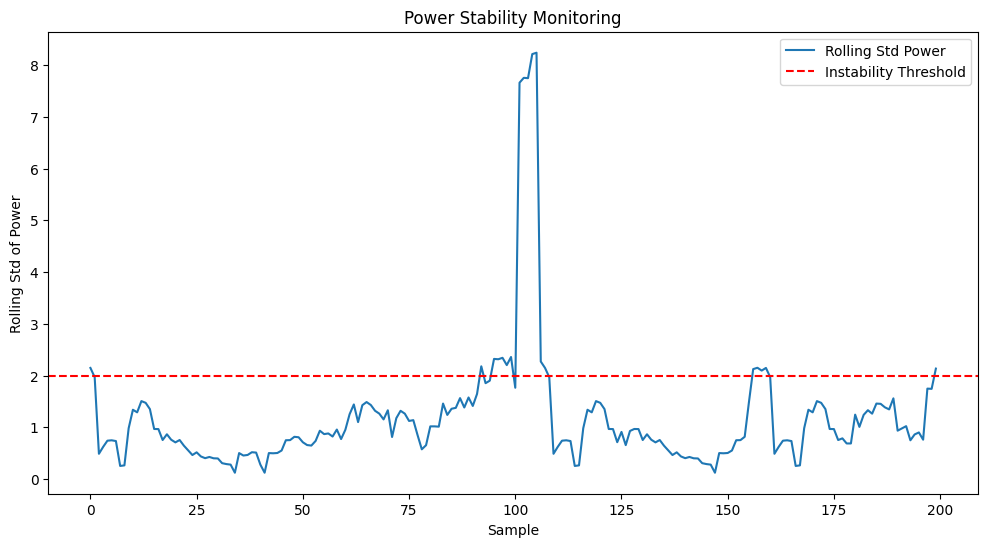

In [75]:
plt.figure(figsize=(12,6))

plt.plot(
    df["RollingStd_Power"].values[:200],
    label="Rolling Std Power"
)

plt.axhline(
    y=2,
    color='r',
    linestyle='--',
    label="Instability Threshold"
)

plt.xlabel("Sample")

plt.ylabel("Rolling Std of Power")

plt.title("Power Stability Monitoring")

plt.legend()

plt.show()

In [76]:
threshold = (
    df["RollingStd_Power"].mean()
    +
    2 * df["RollingStd_Power"].std()
)

print("Threshold:", threshold)

Threshold: 3.0237756947626533


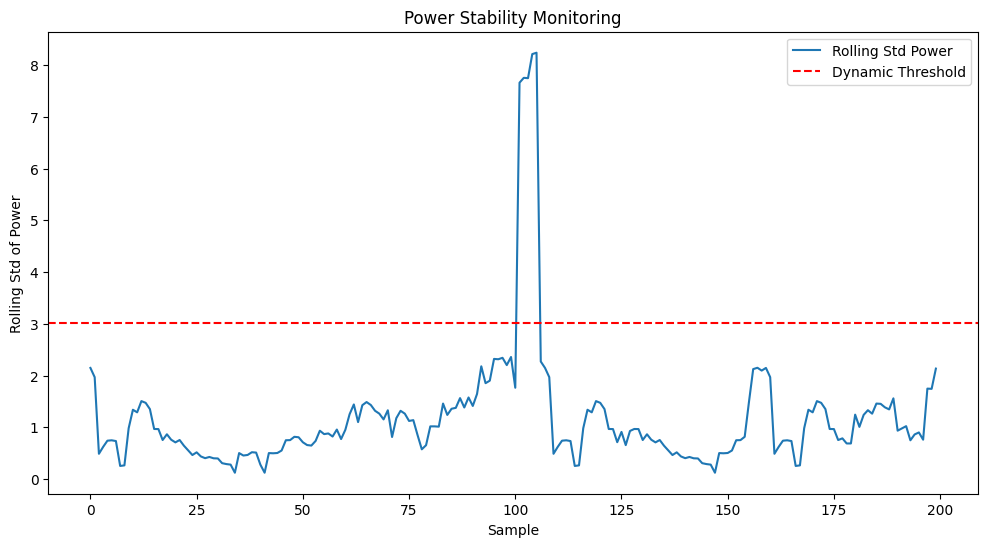

In [77]:
plt.figure(figsize=(12,6))

plt.plot(
    df["RollingStd_Power"].values[:200],
    label="Rolling Std Power"
)

plt.axhline(
    y=threshold,
    color='r',
    linestyle='--',
    label="Dynamic Threshold"
)

plt.xlabel("Sample")

plt.ylabel("Rolling Std of Power")

plt.title("Power Stability Monitoring")

plt.legend()

plt.show()

In [78]:
importance_df_filtered = importance_df[
    importance_df["Feature"] != "LoadType"
]

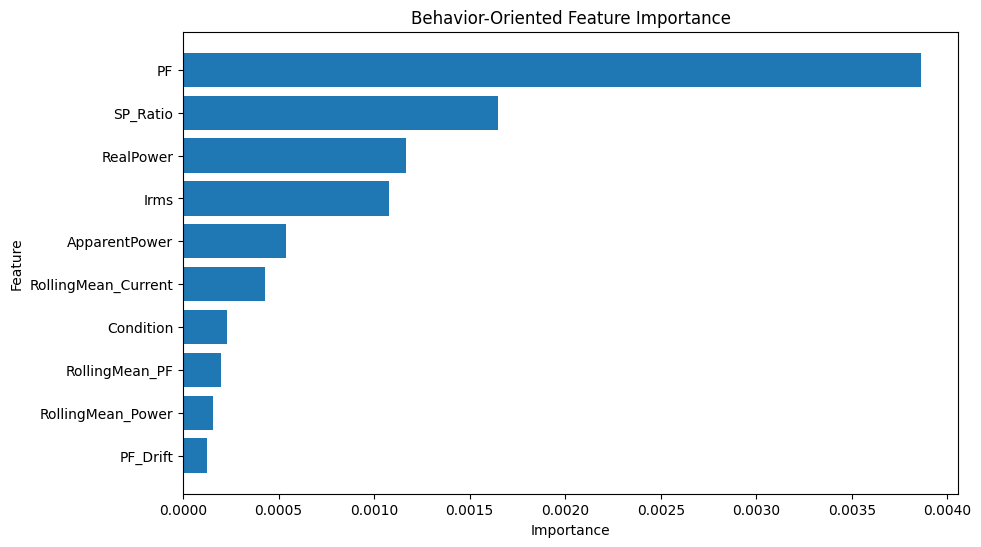

In [79]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df_filtered["Feature"][:10],
    importance_df_filtered["Importance"][:10]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Behavior-Oriented Feature Importance")

plt.gca().invert_yaxis()

plt.show()

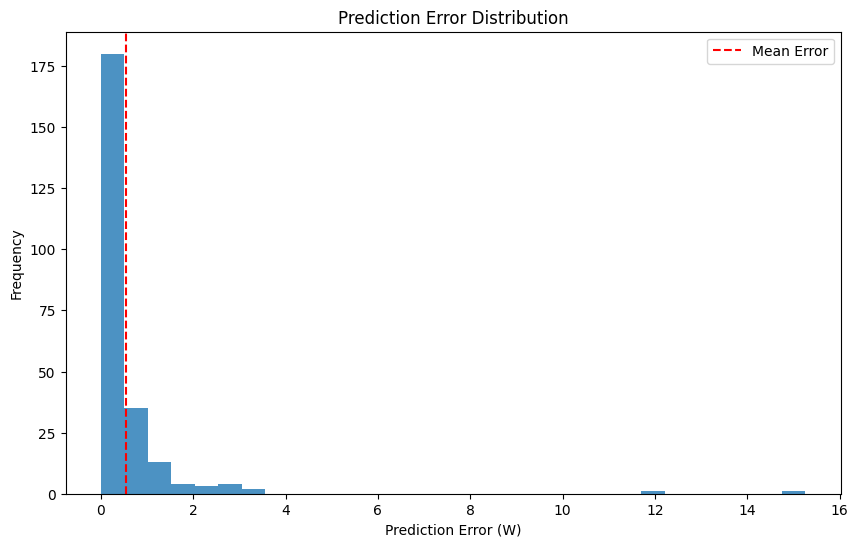

In [80]:
plt.figure(figsize=(10,6))

plt.hist(
    results["PredictionError"],
    bins=30,
    alpha=0.8
)

plt.axvline(
    results["PredictionError"].mean(),
    color='r',
    linestyle='--',
    label="Mean Error"
)

plt.xlabel("Prediction Error (W)")

plt.ylabel("Frequency")

plt.title("Prediction Error Distribution")

plt.legend()

plt.show()

In [81]:
load_names = {
    0: "LED",
    1: "Bulb",
    2: "Fan"
}

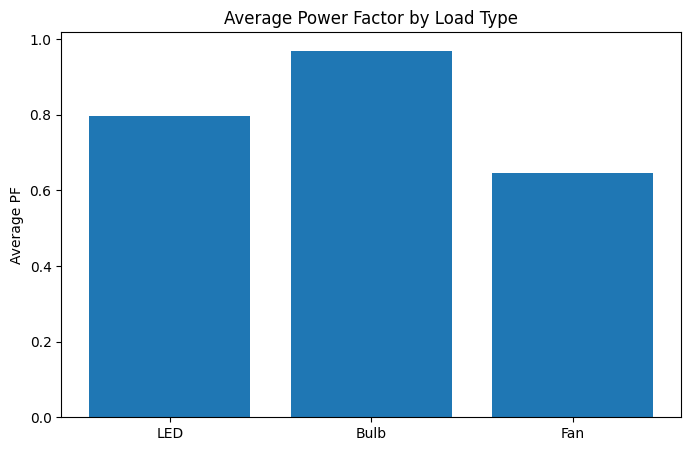

In [82]:
pf_means = df.groupby("LoadType")["PF"].mean()

labels = [
    load_names[i]
    for i in pf_means.index
]

plt.figure(figsize=(8,5))

plt.bar(
    labels,
    pf_means.values
)

plt.ylabel("Average PF")

plt.title("Average Power Factor by Load Type")

plt.show()

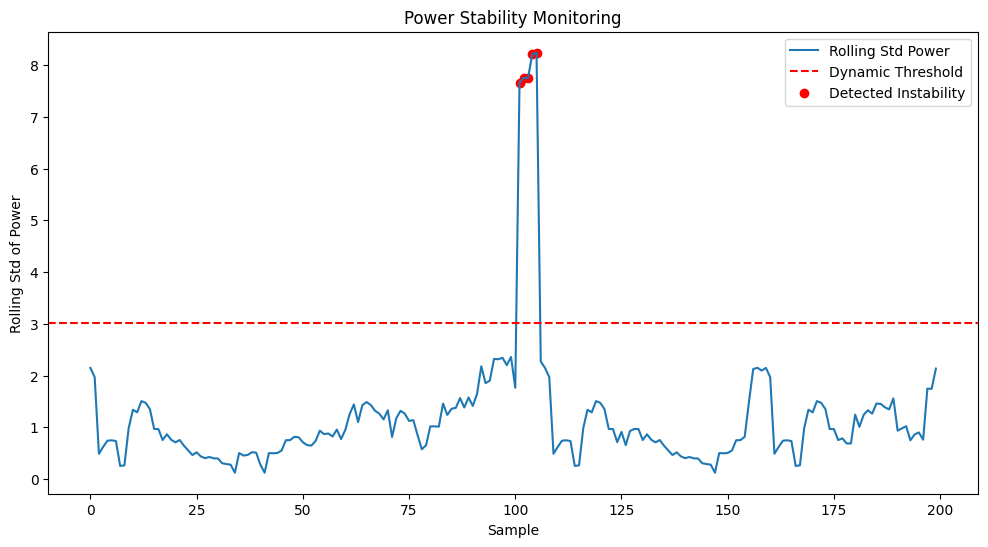

In [83]:
stability = df["RollingStd_Power"].values[:200]

plt.figure(figsize=(12,6))

plt.plot(
    stability,
    label="Rolling Std Power"
)

plt.axhline(
    y=threshold,
    color='r',
    linestyle='--',
    label="Dynamic Threshold"
)

anomaly_idx = [
    i for i, v in enumerate(stability)
    if v > threshold
]

anomaly_vals = [
    v for v in stability
    if v > threshold
]

plt.scatter(
    anomaly_idx,
    anomaly_vals,
    color='red',
    label="Detected Instability"
)

plt.xlabel("Sample")

plt.ylabel("Rolling Std of Power")

plt.title("Power Stability Monitoring")

plt.legend()

plt.show()

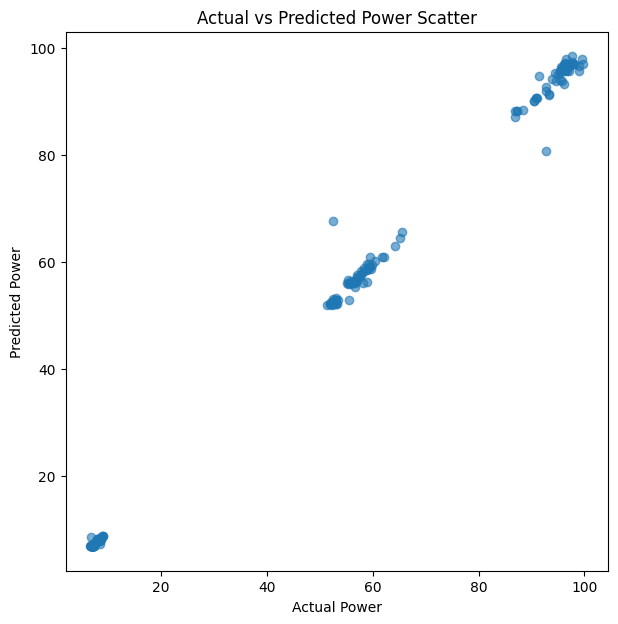

In [84]:
plt.figure(figsize=(7,7))

plt.scatter(
    results["ActualPower"],
    results["PredictedPower"],
    alpha=0.6
)

plt.xlabel("Actual Power")

plt.ylabel("Predicted Power")

plt.title("Actual vs Predicted Power Scatter")

plt.show()

In [85]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=False
)

plt.title("Feature Correlation Heatmap")

plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [86]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


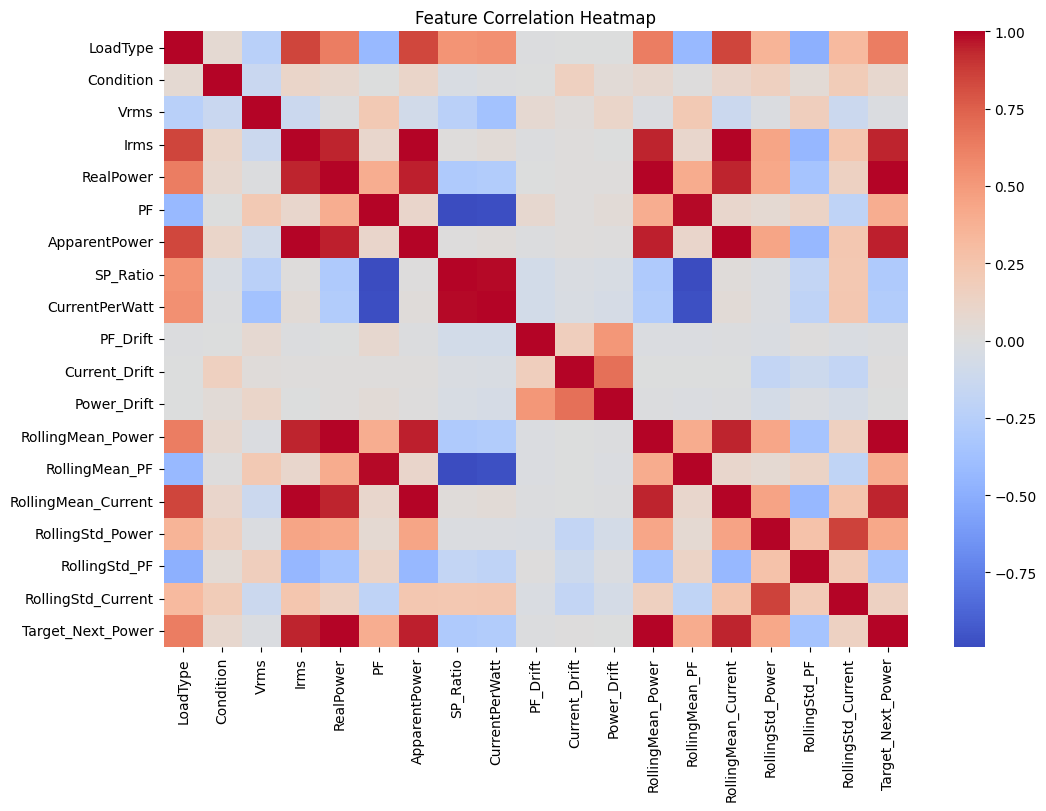

In [87]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=False
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [88]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

NameError: name 'y_pred' is not defined

In [89]:
y_pred = model.predict(X_test)

In [90]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.998412789483177


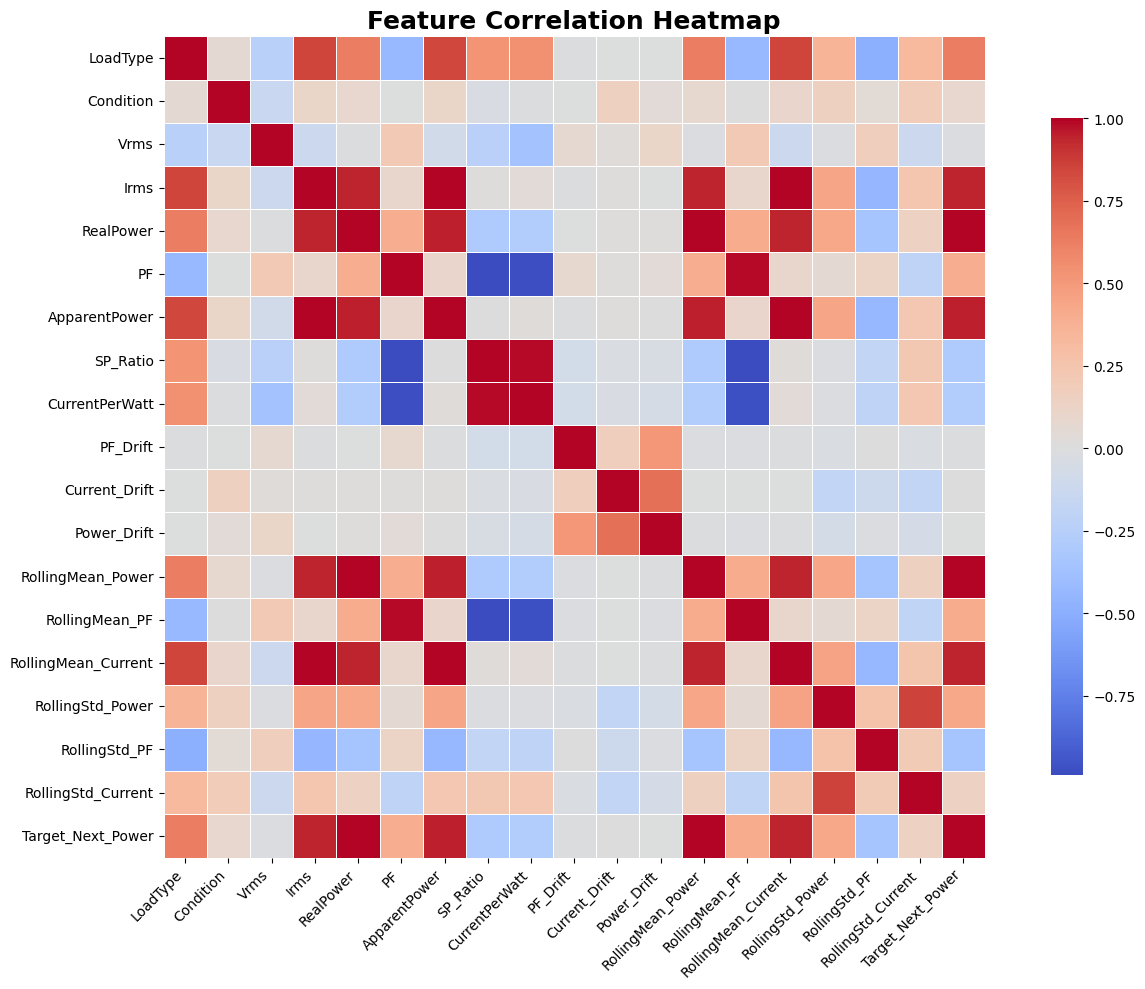

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=18,
    fontweight='bold'
)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.show()

In [92]:
import joblib

joblib.dump(model, "xgboost_power_predictor.pkl")

print("Model saved successfully!")

Model saved successfully!


In [93]:
load_mapping = {
    0: "LED",
    1: "Bulb",
    2: "Fan"
}

condition_mapping = {
    0: "Healthy",
    1: "Mild",
    2: "Moderate"
}

In [94]:
df.to_csv("processed_energy_dataset.csv", index=False)

In [95]:
import json

mappings = {
    "load_mapping": load_mapping,
    "condition_mapping": condition_mapping
}

with open("mappings.json", "w") as f:
    json.dump(mappings, f)

print("Mappings saved successfully!")

Mappings saved successfully!


In [97]:
# Add prediction values into df

df = df.iloc[:len(y_pred)].copy()

df["PredictedPower"] = y_pred

df["PredictionError"] = abs(df["Target_Next_Power"] - df["PredictedPower"])

print(df[["Target_Next_Power",
          "PredictedPower",
          "PredictionError"]].head())

   Target_Next_Power  PredictedPower  PredictionError
4              95.02        6.944947        88.075053
5              94.73        7.039525        87.690475
6              96.24       97.031883         0.791883
7              96.40       97.044434         0.644434
8              95.97       65.621941        30.348059


In [98]:
# -------------------------------
# STABILITY / HEALTH SCORE ENGINE
# -------------------------------

# Normalize instability parameters

error_norm = df["PredictionError"] / df["PredictionError"].max()

std_norm = df["RollingStd_Power"] / df["RollingStd_Power"].max()

pf_drift_norm = abs(df["PF_Drift"]) / abs(df["PF_Drift"]).max()

current_drift_norm = abs(df["Current_Drift"]) / abs(df["Current_Drift"]).max()


# Weighted instability score

instability_score = (
    0.35 * error_norm +
    0.35 * std_norm +
    0.15 * pf_drift_norm +
    0.15 * current_drift_norm
)


# Convert to Health Score

df["HealthScore"] = 100 - (instability_score * 100)

# Keep values between 0 and 100

df["HealthScore"] = df["HealthScore"].clip(0, 100)

print(df[["PredictionError",
          "RollingStd_Power",
          "PF_Drift",
          "Current_Drift",
          "HealthScore"]].head())

   PredictionError  RollingStd_Power  PF_Drift  Current_Drift  HealthScore
4        88.075053          2.148632    -0.006        -0.0004    55.778064
5        87.690475          1.970145     0.000         0.0001    58.432146
6         0.791883          0.489969     0.000         0.0004    97.466843
7         0.644434          0.624155     0.012        -0.0007    93.565808
8        30.348059          0.743135     0.001         0.0002    85.018122


In [99]:
results_df = X_test.copy()

results_df["ActualPower"] = y_test

results_df["PredictedPower"] = y_pred

results_df["PredictionError"] = abs(
    results_df["ActualPower"] -
    results_df["PredictedPower"]
)

results_df.head()

,LoadType,Condition,Vrms,Irms,RealPower,PF,ApparentPower,SP_Ratio,CurrentPerWatt,PF_Drift,...,Power_Drift,RollingMean_Power,RollingMean_PF,RollingMean_Current,RollingStd_Power,RollingStd_PF,RollingStd_Current,ActualPower,PredictedPower,PredictionError
752,0,0,232.6,0.0401,7.16,0.768,9.32726,1.302690,0.005601,0.016,...,0.22,6.960,0.7516,0.04012,0.193003,0.017869,0.000130,6.81,6.944947,0.134947
801,0,0,231.1,0.0401,6.93,0.748,9.26711,1.337245,0.005786,-0.030,...,-0.25,7.068,0.7668,0.03998,0.160219,0.016814,0.000084,6.93,7.039525,0.109525
47,1,0,229.6,0.4248,96.36,0.988,97.53408,1.012184,0.004408,-0.003,...,-1.28,96.770,0.9870,0.42500,0.499600,0.002646,0.000324,96.58,97.031883,0.451883
159,1,0,229.2,0.4247,94.15,0.967,97.34124,1.033895,0.004511,-0.015,...,-1.92,96.394,0.9838,0.42506,1.488180,0.010686,0.000336,99.83,97.044434,2.785566
506,2,3,223.4,0.4278,64.21,0.672,95.57052,1.488406,0.006663,0.012,...,4.66,60.814,0.6648,0.40950,2.032715,0.006099,0.010351,65.58,65.621941,0.041941


In [100]:
# -------------------------------
# STABILITY / HEALTH SCORE ENGINE
# -------------------------------

# Normalize parameters

error_norm = (
    results_df["PredictionError"] /
    results_df["PredictionError"].max()
)

std_norm = (
    results_df["RollingStd_Power"] /
    results_df["RollingStd_Power"].max()
)

pf_drift_norm = (
    abs(results_df["PF_Drift"]) /
    abs(results_df["PF_Drift"]).max()
)

current_drift_norm = (
    abs(results_df["Current_Drift"]) /
    abs(results_df["Current_Drift"]).max()
)

# Weighted instability score

instability_score = (
    0.35 * error_norm +
    0.35 * std_norm +
    0.15 * pf_drift_norm +
    0.15 * current_drift_norm
)

# Final health score

results_df["HealthScore"] = (
    100 - (instability_score * 100)
)

results_df["HealthScore"] = (
    results_df["HealthScore"].clip(0, 100)
)

results_df[[
    "ActualPower",
    "PredictedPower",
    "PredictionError",
    "HealthScore"
]].head()

,ActualPower,PredictedPower,PredictionError,HealthScore
752,6.81,6.944947,0.134947,96.776348
801,6.93,7.039525,0.109525,95.145033
47,96.58,97.031883,0.451883,96.373601
159,99.83,97.044434,2.785566,85.269039
506,65.58,65.621941,0.041941,84.211114


In [101]:
# -------------------------------
# RISK / HEALTH CLASSIFICATION
# -------------------------------

def classify_health(score):

    if score >= 85:
        return "Healthy"

    elif score >= 70:
        return "Mild Risk"

    elif score >= 50:
        return "Moderate Risk"

    else:
        return "Severe Risk"


results_df["HealthStatus"] = (
    results_df["HealthScore"]
    .apply(classify_health)
)

results_df[[
    "ActualPower",
    "PredictedPower",
    "PredictionError",
    "HealthScore",
    "HealthStatus"
]].head(10)

,ActualPower,PredictedPower,PredictionError,HealthScore,HealthStatus
752,6.81,6.944947,0.134947,96.776348,Healthy
801,6.93,7.039525,0.109525,95.145033,Healthy
47,96.58,97.031883,0.451883,96.373601,Healthy
159,99.83,97.044434,2.785566,85.269039,Healthy
506,65.58,65.621941,0.041941,84.211114,Mild Risk
982,8.39,8.146178,0.243822,96.302691,Healthy
282,96.31,96.586357,0.276357,93.221626,Healthy
603,62.08,61.034966,1.045034,58.446564,Moderate Risk
127,96.32,95.636063,0.683937,93.917944,Healthy
117,96.57,96.325195,0.244805,95.888635,Healthy


In [102]:
# -----------------------------------
# EXPLAINABLE FAULT DIAGNOSIS ENGINE
# -----------------------------------

def diagnose_fault(row):

    messages = []

    # Power instability
    if row["RollingStd_Power"] > 3:
        messages.append("High power fluctuation detected")

    # PF degradation
    if abs(row["PF_Drift"]) > 0.01:
        messages.append("Possible power factor degradation")

    # Current instability
    if abs(row["Current_Drift"]) > 0.0005:
        messages.append("Current instability increasing")

    # Prediction abnormality
    if row["PredictionError"] > 2:
        messages.append("Unexpected appliance behavior predicted")

    # Final interpretation
    if len(messages) == 0:
        return "Normal stable operation"

    return " | ".join(messages)


results_df["Diagnosis"] = (
    results_df.apply(diagnose_fault, axis=1)
)

results_df[[
    "ActualPower",
    "PredictedPower",
    "HealthScore",
    "HealthStatus",
    "Diagnosis"
]].head(15)

,ActualPower,PredictedPower,HealthScore,HealthStatus,Diagnosis
752,6.81,6.944947,96.776348,Healthy,Possible power factor degradation
801,6.93,7.039525,95.145033,Healthy,Possible power factor degradation
47,96.58,97.031883,96.373601,Healthy,Current instability increasing
159,99.83,97.044434,85.269039,Healthy,Possible power factor degradation | Current in...
506,65.58,65.621941,84.211114,Mild Risk,Possible power factor degradation | Current in...
982,8.39,8.146178,96.302691,Healthy,Possible power factor degradation
282,96.31,96.586357,93.221626,Healthy,Possible power factor degradation
603,62.08,61.034966,58.446564,Moderate Risk,High power fluctuation detected | Possible pow...
127,96.32,95.636063,93.917944,Healthy,Normal stable operation
117,96.57,96.325195,95.888635,Healthy,Normal stable operation


In [103]:
# -----------------------------------
# SMART EXPLAINABLE DIAGNOSIS ENGINE
# -----------------------------------

def diagnose_fault(row):

    messages = []

    # Severe power instability
    if row["RollingStd_Power"] > 3:
        messages.append("High power fluctuation detected")

    # Moderate instability
    elif row["RollingStd_Power"] > 1.5:
        messages.append("Moderate load instability observed")

    # PF degradation
    if abs(row["PF_Drift"]) > 0.02:
        messages.append("Possible power factor degradation")

    # Current instability
    if abs(row["Current_Drift"]) > 0.0008:
        messages.append("Current instability increasing")

    # Large prediction mismatch
    if row["PredictionError"] > 2:
        messages.append("Unexpected appliance behavior predicted")

    # Very low health
    if row["HealthScore"] < 50:
        messages.append("Maintenance recommended")

    # Final interpretation
    if len(messages) == 0:
        return "Normal stable operation"

    return " | ".join(messages)


results_df["Diagnosis"] = (
    results_df.apply(diagnose_fault, axis=1)
)

results_df[[
    "ActualPower",
    "PredictedPower",
    "HealthScore",
    "HealthStatus",
    "Diagnosis"
]].head(20)

,ActualPower,PredictedPower,HealthScore,HealthStatus,Diagnosis
752,6.81,6.944947,96.776348,Healthy,Normal stable operation
801,6.93,7.039525,95.145033,Healthy,Possible power factor degradation
47,96.58,97.031883,96.373601,Healthy,Normal stable operation
159,99.83,97.044434,85.269039,Healthy,Unexpected appliance behavior predicted
506,65.58,65.621941,84.211114,Mild Risk,Moderate load instability observed | Current i...
982,8.39,8.146178,96.302691,Healthy,Possible power factor degradation
282,96.31,96.586357,93.221626,Healthy,Normal stable operation
603,62.08,61.034966,58.446564,Moderate Risk,High power fluctuation detected | Possible pow...
127,96.32,95.636063,93.917944,Healthy,Normal stable operation
117,96.57,96.325195,95.888635,Healthy,Normal stable operation


In [104]:
# -----------------------------------
# PERSISTENT MAINTENANCE ALERT SYSTEM
# -----------------------------------

alert_counter = 0

maintenance_alerts = []

for status in results_df["HealthStatus"]:

    if status in ["Moderate Risk", "Severe Risk"]:

        alert_counter += 1

    else:
        alert_counter = 0

    # Trigger alert if instability persists
    if alert_counter >= 3:
        maintenance_alerts.append("MAINTENANCE REQUIRED")

    else:
        maintenance_alerts.append("System Normal")


results_df["MaintenanceAlert"] = maintenance_alerts

results_df[[
    "HealthScore",
    "HealthStatus",
    "Diagnosis",
    "MaintenanceAlert"
]].head(25)

,HealthScore,HealthStatus,Diagnosis,MaintenanceAlert
752,96.776348,Healthy,Normal stable operation,System Normal
801,95.145033,Healthy,Possible power factor degradation,System Normal
47,96.373601,Healthy,Normal stable operation,System Normal
159,85.269039,Healthy,Unexpected appliance behavior predicted,System Normal
506,84.211114,Mild Risk,Moderate load instability observed | Current i...,System Normal
982,96.302691,Healthy,Possible power factor degradation,System Normal
282,93.221626,Healthy,Normal stable operation,System Normal
603,58.446564,Moderate Risk,High power fluctuation detected | Possible pow...,System Normal
127,93.917944,Healthy,Normal stable operation,System Normal
117,95.888635,Healthy,Normal stable operation,System Normal


In [105]:
# -----------------------------------
# SMART MAINTENANCE ALERT ENGINE
# -----------------------------------

alert_counter = 0
maintenance_alerts = []

for status in results_df["HealthStatus"]:

    if status in ["Moderate Risk", "Severe Risk"]:
        alert_counter += 1
    else:
        alert_counter = 0

    # Trigger maintenance after 2 consecutive risky states
    if alert_counter >= 2:
        maintenance_alerts.append("MAINTENANCE REQUIRED")
    else:
        maintenance_alerts.append("System Normal")


results_df["MaintenanceAlert"] = maintenance_alerts

In [106]:
# Show only maintenance-triggered cases

maintenance_cases = results_df[
    results_df["MaintenanceAlert"] == "MAINTENANCE REQUIRED"
]

maintenance_cases[[
    "ActualPower",
    "PredictedPower",
    "HealthScore",
    "HealthStatus",
    "Diagnosis",
    "MaintenanceAlert"
]].head(20)

,ActualPower,PredictedPower,HealthScore,HealthStatus,Diagnosis,MaintenanceAlert


In [107]:
results_df["HealthStatus"].value_counts()

HealthStatus
Healthy          230
Moderate Risk      6
Mild Risk          5
Severe Risk        2
Name: count, dtype: int64

In [108]:
# -----------------------------------
# ADVANCED MAINTENANCE ALERT ENGINE
# -----------------------------------

risk_flags = results_df["HealthStatus"].isin(
    ["Moderate Risk", "Severe Risk"]
).astype(int)

# Rolling abnormal behavior detection
risk_window = risk_flags.rolling(window=5).sum()

results_df["MaintenanceAlert"] = np.where(
    risk_window >= 2,
    "MAINTENANCE REQUIRED",
    "System Normal"
)

In [109]:
maintenance_cases = results_df[
    results_df["MaintenanceAlert"] == "MAINTENANCE REQUIRED"
]

maintenance_cases[[
    "ActualPower",
    "PredictedPower",
    "HealthScore",
    "HealthStatus",
    "Diagnosis",
    "MaintenanceAlert"
]].head(20)

,ActualPower,PredictedPower,HealthScore,HealthStatus,Diagnosis,MaintenanceAlert


In [110]:
results_df = results_df.reset_index(drop=True)

In [124]:
# -----------------------------------
# ADVANCED MAINTENANCE ALERT ENGINE
# -----------------------------------

risk_flags = results_df["HealthStatus"].isin(
    ["Moderate Risk", "Severe Risk"]
).astype(int)

risk_window = risk_flags.rolling(window=5).sum()

results_df["MaintenanceAlert"] = np.where(
    risk_window >= 1 & (results_df["HealthScore"] < 70),
    "MAINTENANCE REQUIRED",
    "System Normal"
)

In [125]:
maintenance_cases = results_df[
    results_df["MaintenanceAlert"] == "MAINTENANCE REQUIRED"
]

maintenance_cases[[
    "ActualPower",
    "PredictedPower",
    "HealthScore",
    "HealthStatus",
    "Diagnosis",
    "MaintenanceAlert"
]].head(20)

,ActualPower,PredictedPower,HealthScore,HealthStatus,Diagnosis,MaintenanceAlert
4,65.58,65.621941,84.211114,Mild Risk,Moderate load instability observed | Current i...,MAINTENANCE REQUIRED
5,8.39,8.146178,96.302691,Healthy,Possible power factor degradation,MAINTENANCE REQUIRED
6,96.31,96.586357,93.221626,Healthy,Normal stable operation,MAINTENANCE REQUIRED
7,62.08,61.034966,58.446564,Moderate Risk,High power fluctuation detected | Possible pow...,MAINTENANCE REQUIRED
8,96.32,95.636063,93.917944,Healthy,Normal stable operation,MAINTENANCE REQUIRED
9,96.57,96.325195,95.888635,Healthy,Normal stable operation,MAINTENANCE REQUIRED
10,8.38,8.172545,95.385124,Healthy,Possible power factor degradation,MAINTENANCE REQUIRED
11,96.27,96.061829,93.852516,Healthy,Normal stable operation,MAINTENANCE REQUIRED
12,6.97,7.083640,96.344894,Healthy,Possible power factor degradation,MAINTENANCE REQUIRED
13,56.43,56.421562,92.155636,Healthy,Moderate load instability observed,MAINTENANCE REQUIRED


In [126]:
print(risk_window.value_counts())

HealthStatus
0.0    199
1.0     40
Name: count, dtype: int64


In [127]:
maintenance_cases = results_df[
    results_df["MaintenanceAlert"] == "MAINTENANCE REQUIRED"
]

maintenance_cases[[
    "ActualPower",
    "PredictedPower",
    "HealthScore",
    "HealthStatus",
    "Diagnosis",
    "MaintenanceAlert"
]].head(20)

,ActualPower,PredictedPower,HealthScore,HealthStatus,Diagnosis,MaintenanceAlert
4,65.58,65.621941,84.211114,Mild Risk,Moderate load instability observed | Current i...,MAINTENANCE REQUIRED
5,8.39,8.146178,96.302691,Healthy,Possible power factor degradation,MAINTENANCE REQUIRED
6,96.31,96.586357,93.221626,Healthy,Normal stable operation,MAINTENANCE REQUIRED
7,62.08,61.034966,58.446564,Moderate Risk,High power fluctuation detected | Possible pow...,MAINTENANCE REQUIRED
8,96.32,95.636063,93.917944,Healthy,Normal stable operation,MAINTENANCE REQUIRED
9,96.57,96.325195,95.888635,Healthy,Normal stable operation,MAINTENANCE REQUIRED
10,8.38,8.172545,95.385124,Healthy,Possible power factor degradation,MAINTENANCE REQUIRED
11,96.27,96.061829,93.852516,Healthy,Normal stable operation,MAINTENANCE REQUIRED
12,6.97,7.083640,96.344894,Healthy,Possible power factor degradation,MAINTENANCE REQUIRED
13,56.43,56.421562,92.155636,Healthy,Moderate load instability observed,MAINTENANCE REQUIRED


In [128]:
results_df.to_csv("final_energy_monitoring_results.csv", index=False)

In [129]:
import json

mappings = {
    "LoadType": load_mapping,
    "Condition": condition_mapping
}

with open("mappings.json", "w") as f:
    json.dump(mappings, f, indent=4)